# Naive vs reconvolution lifetime fitting

This notebook compares two approaches for estimating fluorescence lifetimes from synthetic TCSPC histograms:

1. a naive mono-exponential fit that ignores the instrument response function (IRF);
2. a reconvolution fit that explicitly includes the IRF in the forward model.

Synthetic measurements are generated according to

$$
N_i \sim \operatorname{Poisson}(\mu_i),
$$

with

$$
\mu(t) = A[\mathrm{IRF} * I_\tau](t) + B.
$$

The main goal is to investigate how the lifetime bias depends on the ratio between the true lifetime and the IRF width.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tcspc_toolkit.convolution import convolve_decay_with_irf
from tcspc_toolkit.fitting import (
    fit_monoexponential_decay,
    fit_monoexponential_reconvolution,
)
from tcspc_toolkit.irf import (
    generate_gaussian_irf,
    normalize_irf,
)
from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import sample_photon_counts

## Measurement time axis

We use the same uniformly spaced time grid for the decay, IRF, convolution, and measured histogram.

In [2]:
time = np.linspace(
    0.0,
    10.0,
    1001,
)

dt = time[1] - time[0]

print(f"Number of bins: {time.size}")
print(f"Bin width: {dt:.4f} ns")

Number of bins: 1001
Bin width: 0.0100 ns


In [3]:
irf_centre = 1.0
irf_fwhm = 0.2

irf = generate_gaussian_irf(
    time=time,
    centre=irf_centre,
    fwhm=irf_fwhm,
    amplitude=1.0,
)

irf = normalize_irf(
    time=time,
    irf=irf,
)

In [4]:
irf_area = np.trapezoid(
    irf,
    x=time,
)

print(f"Integrated IRF area: {irf_area:.6f}")

Integrated IRF area: 1.000000


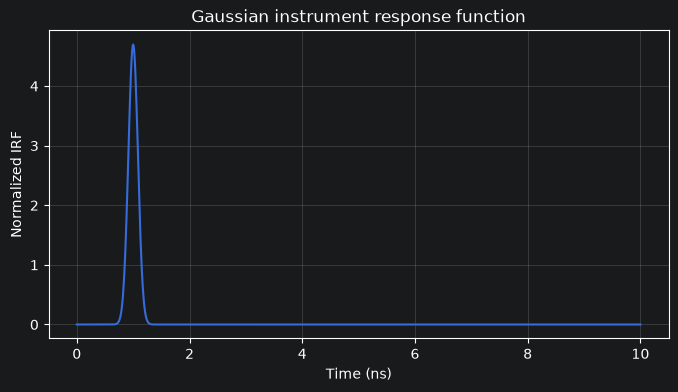

In [5]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    irf,
)

plt.xlabel("Time (ns)")
plt.ylabel("Normalized IRF")
plt.title("Gaussian instrument response function")
plt.grid(alpha=0.3)

plt.show()

## Representative lifetime regimes

We first inspect four lifetimes corresponding to very different ratios between the lifetime and the IRF FWHM:

$$
\tau = 10\,\mathrm{FWHM}_{\mathrm{IRF}},
$$

$$
\tau = 3\,\mathrm{FWHM}_{\mathrm{IRF}},
$$

$$
\tau = \mathrm{FWHM}_{\mathrm{IRF}},
$$

and

$$
\tau = 0.5\,\mathrm{FWHM}_{\mathrm{IRF}}.
$$

In [6]:
lifetime_ratios = np.array([
    10.0,
    3.0,
    1.0,
    0.5,
])

representative_lifetimes = (
    lifetime_ratios * irf_fwhm
)

representative_lifetimes

array([2. , 0.6, 0.2, 0.1])

In [7]:
target_signal_photons = 100_000
background = 2.0

rng = np.random.default_rng(42)

In [8]:
def generate_reconvolved_measurement(
    true_lifetime,
    rng,
):
    unit_decay = monoexponential_decay(
        time=time,
        amplitude=1.0,
        lifetime=true_lifetime,
        background=0.0,
    )

    unit_convolved = convolve_decay_with_irf(
        time=time,
        decay=unit_decay,
        irf=irf,
    )

    amplitude = (
        target_signal_photons
        / unit_convolved.sum()
    )

    expected_counts = (
        amplitude * unit_convolved
        + background
    )

    measured_counts = sample_photon_counts(
        expected_counts=expected_counts,
        rng=rng,
    )

    return (
        amplitude,
        expected_counts,
        measured_counts,
    )

In [9]:
true_lifetime = 2.0

(
    true_amplitude,
    expected_counts,
    measured_counts,
) = generate_reconvolved_measurement(
    true_lifetime=true_lifetime,
    rng=rng,
)

print(f"True lifetime: {true_lifetime:.3f} ns")
print(f"Amplitude: {true_amplitude:.3f}")
print(f"Measured total counts: {measured_counts.sum()}")

True lifetime: 2.000 ns
Amplitude: 504.332
Measured total counts: 101867


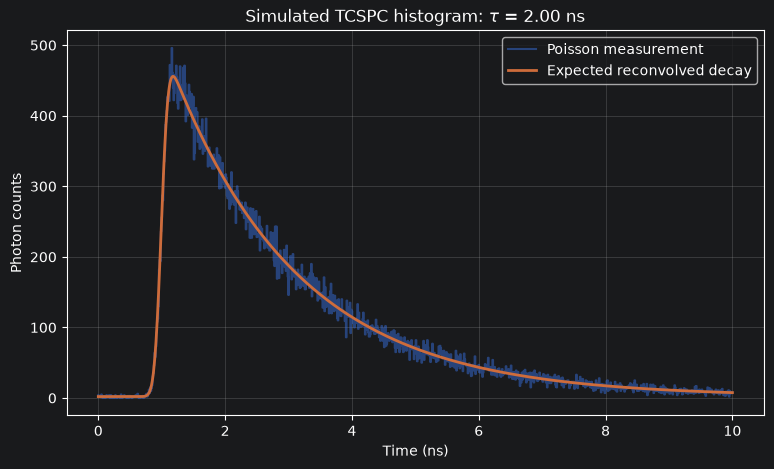

In [10]:
plt.figure(figsize=(9, 5))

plt.step(
    time,
    measured_counts,
    where="mid",
    alpha=0.5,
    label="Poisson measurement",
)

plt.plot(
    time,
    expected_counts,
    linewidth=2,
    label="Expected reconvolved decay",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts")
plt.title(
    f"Simulated TCSPC histogram: "
    f"$\\tau$ = {true_lifetime:.2f} ns"
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Naive fitter

In [11]:
peak_index = int(
    np.argmax(measured_counts)
)

naive_time = (
    time[peak_index:]
    - time[peak_index]
)

naive_counts = measured_counts[peak_index:]

print(f"Peak time: {time[peak_index]:.3f} ns")
print(f"Naive fit bins: {naive_time.size}")

Peak time: 1.160 ns
Naive fit bins: 885


In [12]:
background_guess = float(
    np.median(naive_counts[-100:])
)

amplitude_guess = max(
    float(naive_counts[0]) - background_guess,
    1.0,
)

lifetime_guess = 1.0

naive_initial_guess = (
    amplitude_guess,
    lifetime_guess,
    background_guess,
)

naive_initial_guess

(487.0, 1.0, 9.0)

In [13]:
naive_result = fit_monoexponential_decay(
    time=naive_time,
    counts=naive_counts,
    initial_guess=naive_initial_guess,
)

print(f"True lifetime:  {true_lifetime:.4f} ns")
print(f"Naive lifetime: {naive_result.lifetime:.4f} ns")

True lifetime:  2.0000 ns
Naive lifetime: 1.9961 ns


In [14]:
naive_fitted_curve = monoexponential_decay(
    time=naive_time,
    amplitude=naive_result.amplitude,
    lifetime=naive_result.lifetime,
    background=naive_result.background,
)

## Reconvolution fitter

In [15]:
initial_decay = monoexponential_decay(
    time=time,
    amplitude=1.0,
    lifetime=naive_result.lifetime,
    background=0.0,
)

initial_convolved = convolve_decay_with_irf(
    time=time,
    decay=initial_decay,
    irf=irf,
)

estimated_signal_counts = max(
    measured_counts.sum()
    - background_guess * measured_counts.size,
    1.0,
)

reconvolution_amplitude_guess = (
    estimated_signal_counts
    / initial_convolved.sum()
)

reconvolution_initial_guess = (
    reconvolution_amplitude_guess,
    naive_result.lifetime,
    background_guess,
    0.0,
)

In [16]:
reconvolution_result = (
    fit_monoexponential_reconvolution(
        time=time,
        counts=measured_counts,
        irf=irf,
        initial_guess=reconvolution_initial_guess,
        temporal_shift_bounds=(-0.5, 0.5),
    )
)

In [17]:
print(f"True lifetime:          {true_lifetime:.4f} ns")
print(f"Naive lifetime:         {naive_result.lifetime:.4f} ns")
print(
    f"Reconvolution lifetime: "
    f"{reconvolution_result.lifetime:.4f} ns"
)
print(
    f"Temporal shift:         "
    f"{reconvolution_result.temporal_shift:.4f} ns"
)
print(
    f"Fit successful:         "
    f"{reconvolution_result.success}"
)

True lifetime:          2.0000 ns
Naive lifetime:         1.9961 ns
Reconvolution lifetime: 1.9865 ns
Temporal shift:         0.0025 ns
Fit successful:         True


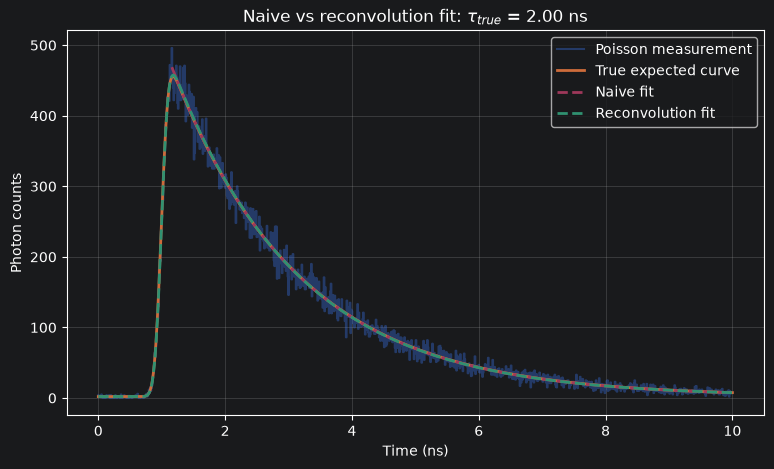

In [18]:
plt.figure(figsize=(9, 5))

plt.step(
    time,
    measured_counts,
    where="mid",
    alpha=0.4,
    label="Poisson measurement",
)

plt.plot(
    time,
    expected_counts,
    linewidth=2,
    label="True expected curve",
)

plt.plot(
    naive_time + time[peak_index],
    naive_fitted_curve,
    linewidth=2,
    linestyle="--",
    label="Naive fit",
)

plt.plot(
    time,
    reconvolution_result.fitted_curve,
    linewidth=2,
    linestyle="--",
    label="Reconvolution fit",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts")
plt.title(
    f"Naive vs reconvolution fit: "
    f"$\\tau_{{true}}$ = {true_lifetime:.2f} ns"
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
naive_relative_error = (
    naive_result.lifetime - true_lifetime
) / true_lifetime

reconvolution_relative_error = (
    reconvolution_result.lifetime
    - true_lifetime
) / true_lifetime

print(
    f"Naive relative error: "
    f"{100 * naive_relative_error:.2f}%"
)

print(
    f"Reconvolution relative error: "
    f"{100 * reconvolution_relative_error:.2f}%"
)

Naive relative error: -0.20%
Reconvolution relative error: -0.67%


In [20]:
def compare_fits(
    true_lifetime,
    rng,
):
    (
        true_amplitude,
        expected_counts,
        measured_counts,
    ) = generate_reconvolved_measurement(
        true_lifetime=true_lifetime,
        rng=rng,
    )

    peak_index = int(
        np.argmax(measured_counts)
    )

    naive_time = (
        time[peak_index:]
        - time[peak_index]
    )

    naive_counts = measured_counts[peak_index:]

    background_guess = float(
        np.median(naive_counts[-100:])
    )

    amplitude_guess = max(
        float(naive_counts[0])
        - background_guess,
        1.0,
    )

    naive_result = fit_monoexponential_decay(
        time=naive_time,
        counts=naive_counts,
        initial_guess=(
            amplitude_guess,
            1.0,
            background_guess,
        ),
    )

    initial_decay = monoexponential_decay(
        time=time,
        amplitude=1.0,
        lifetime=naive_result.lifetime,
        background=0.0,
    )

    initial_convolved = (
        convolve_decay_with_irf(
            time=time,
            decay=initial_decay,
            irf=irf,
        )
    )

    estimated_signal_counts = max(
        measured_counts.sum()
        - background_guess * measured_counts.size,
        1.0,
    )

    reconvolution_amplitude_guess = (
        estimated_signal_counts
        / initial_convolved.sum()
    )

    reconvolution_result = (
        fit_monoexponential_reconvolution(
            time=time,
            counts=measured_counts,
            irf=irf,
            initial_guess=(
                reconvolution_amplitude_guess,
                naive_result.lifetime,
                background_guess,
                0.0,
            ),
            temporal_shift_bounds=(-0.5, 0.5),
        )
    )

    naive_relative_error = (
        naive_result.lifetime
        - true_lifetime
    ) / true_lifetime

    reconvolution_relative_error = (
        reconvolution_result.lifetime
        - true_lifetime
    ) / true_lifetime

    return {
        "true_lifetime": true_lifetime,
        "tau_over_fwhm": (
            true_lifetime / irf_fwhm
        ),
        "naive_lifetime": (
            naive_result.lifetime
        ),
        "reconvolution_lifetime": (
            reconvolution_result.lifetime
        ),
        "naive_relative_error": (
            naive_relative_error
        ),
        "reconvolution_relative_error": (
            reconvolution_relative_error
        ),
        "reconvolution_success": (
            reconvolution_result.success
        ),
        "expected_counts": expected_counts,
        "measured_counts": measured_counts,
        "peak_index": peak_index,
        "naive_fitted_curve": (
            monoexponential_decay(
                time=naive_time,
                amplitude=naive_result.amplitude,
                lifetime=naive_result.lifetime,
                background=naive_result.background,
            )
        ),
        "reconvolution_fitted_curve": (
            reconvolution_result.fitted_curve
        ),
    }

In [21]:
rng = np.random.default_rng(42)

representative_results = []

for true_lifetime in representative_lifetimes:
    result = compare_fits(
        true_lifetime=true_lifetime,
        rng=rng,
    )

    representative_results.append(result)

In [22]:
representative_table = pd.DataFrame(
    [
        {
            "tau_true_ns": result[
                "true_lifetime"
            ],
            "tau_over_fwhm": result[
                "tau_over_fwhm"
            ],
            "tau_naive_ns": result[
                "naive_lifetime"
            ],
            "tau_reconv_ns": result[
                "reconvolution_lifetime"
            ],
            "naive_error_percent": (
                100
                * result[
                    "naive_relative_error"
                ]
            ),
            "reconv_error_percent": (
                100
                * result[
                    "reconvolution_relative_error"
                ]
            ),
        }
        for result in representative_results
    ]
)

representative_table

,tau_true_ns,tau_over_fwhm,tau_naive_ns,tau_reconv_ns,naive_error_percent,reconv_error_percent
0,2.0,10.0,1.996063,1.986538,-0.196871,-0.673082
1,0.6,3.0,0.617760,0.603421,2.960069,0.570216
2,0.2,1.0,0.232968,0.201370,16.484129,0.685172
3,0.1,0.5,0.144597,0.099278,44.597016,-0.721511


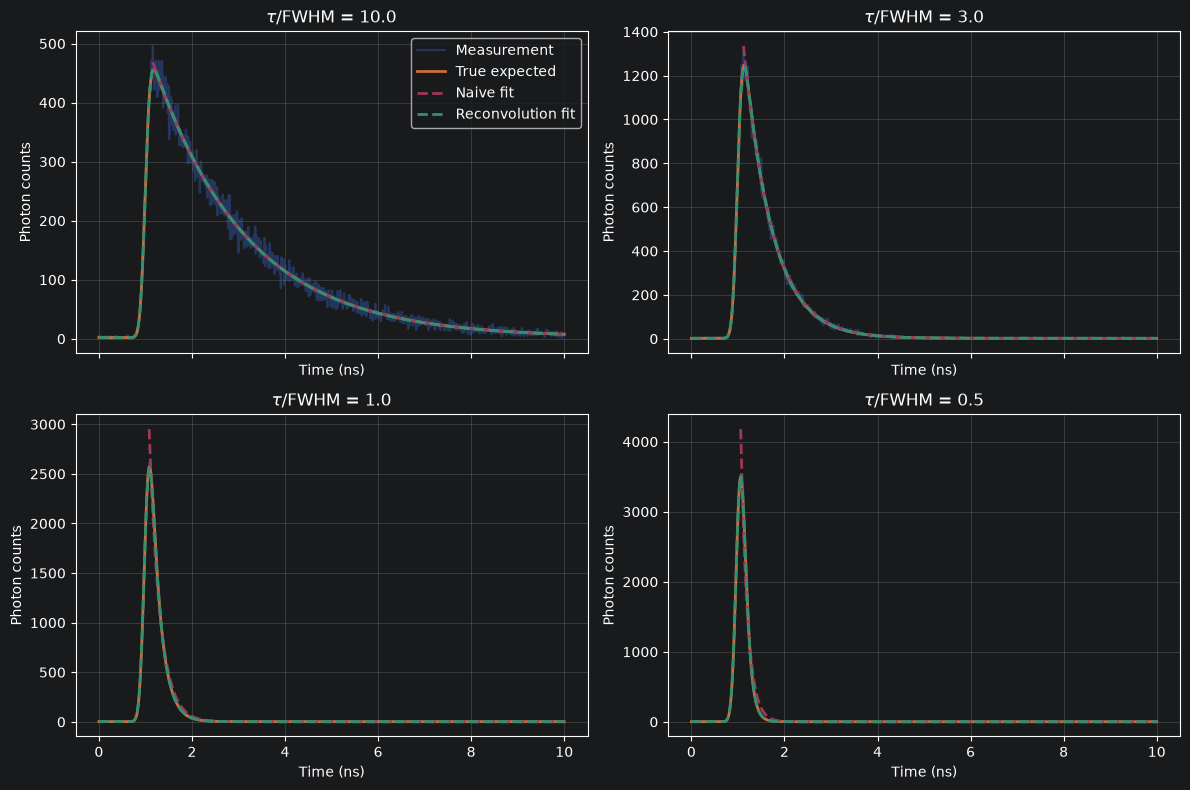

In [23]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
)

for ax, result in zip(
    axes.flat,
    representative_results,
):
    peak_index = result["peak_index"]

    naive_plot_time = (
        time[peak_index:]
    )

    ax.step(
        time,
        result["measured_counts"],
        where="mid",
        alpha=0.35,
        label="Measurement",
    )

    ax.plot(
        time,
        result["expected_counts"],
        linewidth=2,
        label="True expected",
    )

    ax.plot(
        naive_plot_time,
        result["naive_fitted_curve"],
        linestyle="--",
        linewidth=2,
        label="Naive fit",
    )

    ax.plot(
        time,
        result[
            "reconvolution_fitted_curve"
        ],
        linestyle="--",
        linewidth=2,
        label="Reconvolution fit",
    )

    ax.set_title(
        f"$\\tau$/FWHM = "
        f"{result['tau_over_fwhm']:.1f}"
    )

    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Photon counts")
    ax.grid(alpha=0.3)

axes[0, 0].legend()

plt.tight_layout()
plt.show()

In [24]:
sweep_ratios = np.array([
    0.25,
    0.5,
    0.75,
    1.0,
    1.5,
    2.0,
    3.0,
    5.0,
    10.0,
    20.0,
])

sweep_lifetimes = (
    sweep_ratios * irf_fwhm
)

In [25]:
rng = np.random.default_rng(123)

sweep_results = []

for true_lifetime in sweep_lifetimes:
    result = compare_fits(
        true_lifetime=true_lifetime,
        rng=rng,
    )

    sweep_results.append(result)

In [26]:
naive_errors = np.array(
    [
        result["naive_relative_error"]
        for result in sweep_results
    ]
)

reconvolution_errors = np.array(
    [
        result[
            "reconvolution_relative_error"
        ]
        for result in sweep_results
    ]
)

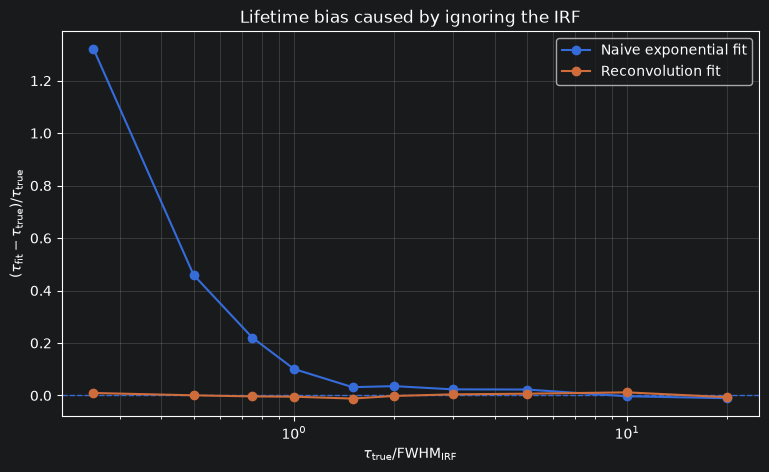

In [27]:
plt.figure(figsize=(9, 5))

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

plt.plot(
    sweep_ratios,
    naive_errors,
    marker="o",
    label="Naive exponential fit",
)

plt.plot(
    sweep_ratios,
    reconvolution_errors,
    marker="o",
    label="Reconvolution fit",
)

plt.xscale("log")

plt.xlabel(
    r"$\tau_{\mathrm{true}}"
    r"/\mathrm{FWHM}_{\mathrm{IRF}}$"
)

plt.ylabel(
    r"$(\tau_{\mathrm{fit}}"
    r"-\tau_{\mathrm{true}})"
    r"/\tau_{\mathrm{true}}$"
)

plt.title(
    "Lifetime bias caused by ignoring the IRF"
)

plt.legend()
plt.grid(
    alpha=0.3,
    which="both",
)

plt.show()

In [28]:
n_realizations = 100

naive_error_samples = np.full(
    (
        sweep_ratios.size,
        n_realizations,
    ),
    np.nan,
)

reconvolution_error_samples = np.full(
    (
        sweep_ratios.size,
        n_realizations,
    ),
    np.nan,
)

In [29]:
rng = np.random.default_rng(2026)

for lifetime_index, true_lifetime in enumerate(
    sweep_lifetimes
):
    for realization_index in range(
        n_realizations
    ):
        try:
            result = compare_fits(
                true_lifetime=true_lifetime,
                rng=rng,
            )

            naive_error_samples[
                lifetime_index,
                realization_index,
            ] = result[
                "naive_relative_error"
            ]

            if result[
                "reconvolution_success"
            ]:
                reconvolution_error_samples[
                    lifetime_index,
                    realization_index,
                ] = result[
                    "reconvolution_relative_error"
                ]

        except (RuntimeError, ValueError):
            continue

In [30]:
naive_median = np.nanmedian(
    naive_error_samples,
    axis=1,
)

naive_lower = np.nanpercentile(
    naive_error_samples,
    16,
    axis=1,
)

naive_upper = np.nanpercentile(
    naive_error_samples,
    84,
    axis=1,
)

reconvolution_median = np.nanmedian(
    reconvolution_error_samples,
    axis=1,
)

reconvolution_lower = np.nanpercentile(
    reconvolution_error_samples,
    16,
    axis=1,
)

reconvolution_upper = np.nanpercentile(
    reconvolution_error_samples,
    84,
    axis=1,
)

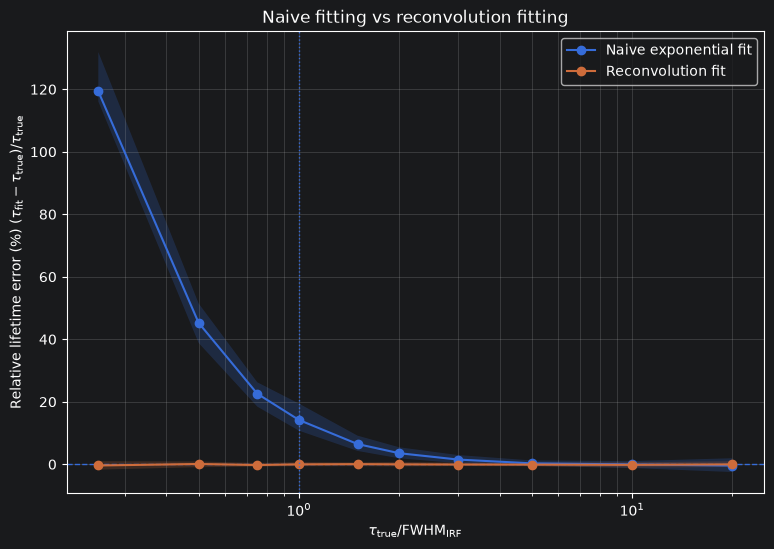

In [31]:
plt.figure(figsize=(9, 6))

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

plt.plot(
    sweep_ratios,
    100 * naive_median,
    marker="o",
    label="Naive exponential fit",
)

plt.fill_between(
    sweep_ratios,
    100 * naive_lower,
    100 * naive_upper,
    alpha=0.2,
)

plt.plot(
    sweep_ratios,
    100 * reconvolution_median,
    marker="o",
    label="Reconvolution fit",
)

plt.fill_between(
    sweep_ratios,
    100 * reconvolution_lower,
    100 * reconvolution_upper,
    alpha=0.2,
)

plt.xscale("log")

plt.axvline(
    1.0,
    linestyle=":",
    linewidth=1,
)

plt.xlabel(
    r"$\tau_{\mathrm{true}}"
    r"/\mathrm{FWHM}_{\mathrm{IRF}}$"
)

plt.ylabel(
    r"Relative lifetime error (%) "
    r"$(\tau_{\mathrm{fit}}"
    r"-\tau_{\mathrm{true}})"
    r"/\tau_{\mathrm{true}}$"
)

plt.title(
    "Naive fitting vs reconvolution fitting"
)

plt.legend()

plt.grid(
    alpha=0.3,
    which="both",
)

plt.show()

In [32]:
naive_success_counts = np.sum(
    np.isfinite(naive_error_samples),
    axis=1,
)

reconvolution_success_counts = np.sum(
    np.isfinite(
        reconvolution_error_samples
    ),
    axis=1,
)

success_table = pd.DataFrame(
    {
        "tau_over_fwhm": sweep_ratios,
        "naive_successes": (
            naive_success_counts
        ),
        "reconvolution_successes": (
            reconvolution_success_counts
        ),
        "total_realizations": (
            n_realizations
        ),
    }
)

success_table

,tau_over_fwhm,naive_successes,reconvolution_successes,total_realizations
0,0.25,100,100,100
1,0.50,100,100,100
2,0.75,100,100,100
3,1.00,100,100,100
4,1.50,100,100,100
5,2.00,100,100,100
6,3.00,100,100,100
7,5.00,100,100,100
8,10.00,100,100,100
9,20.00,100,100,100


## Interpretation

The comparison demonstrates that ignoring the instrument response function can introduce systematic lifetime bias when the fluorescence lifetime approaches the temporal width of the IRF.

For

$$
\tau_{\mathrm{true}} \gg \mathrm{FWHM}_{\mathrm{IRF}},
$$

the fluorescence decay evolves on a much slower timescale than the instrument response, and a simple exponential fit can provide a reasonable approximation.

As

$$
\tau_{\mathrm{true}} \rightarrow \mathrm{FWHM}_{\mathrm{IRF}},
$$

the measured histogram becomes increasingly shaped by the IRF. The naive exponential model cannot represent this instrumental broadening and therefore compensates by changing its estimated lifetime.

The reconvolution model instead compares the measurement with a forward model of the complete measurement process,

$$
\mu(t)=A[\mathrm{IRF}_{\Delta t}*I_\tau](t)+B,
$$

and can therefore substantially reduce model-induced lifetime bias.

For lifetimes shorter than the IRF width, the lifetime can become increasingly difficult to identify even with the correct reconvolution model. In this regime, increased statistical uncertainty should be distinguished from systematic bias caused by fitting an incorrect model.

Both fitting approaches used here still rely on ordinary least-squares objectives. The next step is therefore to investigate objective functions that explicitly account for Poisson photon-counting statistics.